각 변수는 어떤 값을 갖는가
각 품종의 데이터 수는 동일한가
꽃잎과 꽃받침의 크기 분포
이상치로 보이는 값의 유무
꽃잎 길이와 너비의 관계
품종에 따른 측정값의 분포
여러 수치형 변수 중 강한 관계를 갖는 변수

In [48]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris

In [49]:
sns.set_theme(context='notebook',style='darkgrid')

In [ ]:
iris= load_iris(as_frame=True)

df = iris.frame.copy()

df.sample(5)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
50,7.0,3.2,4.7,1.4,1
94,5.6,2.7,4.2,1.3,1
59,5.2,2.7,3.9,1.4,1
34,4.9,3.1,1.5,0.2,0
8,4.4,2.9,1.4,0.2,0


In [51]:
df.columns

Index(['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)',
       'petal width (cm)', 'target'],
      dtype='str')

In [52]:
df =df.rename(columns={'sepal length (cm)': 'sepal_length', 'sepal width (cm)':'sepal_width',
                    'petal length (cm)':'petal_length','petal width (cm)':'petal_width',})

In [53]:
iris.target_names

array(['setosa', 'versicolor', 'virginica'], dtype='<U10')

In [54]:
target_map=dict(enumerate(iris.target_names))   #배열 -> 순서값 넣기 -> 딕션어리

df['species']=df['target'].map(target_map)

df= df.drop(columns='target')

In [55]:
df.shape

(150, 5)

In [56]:
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [57]:
df.dtypes

sepal_length    float64
sepal_width     float64
petal_length    float64
petal_width     float64
species             str
dtype: object

In [58]:
numeric_col=df.select_dtypes(include='number').columns.to_list()
print(numeric_col)

['sepal_length', 'sepal_width', 'petal_length', 'petal_width']


In [59]:
categorical_col=df.select_dtypes(exclude='number').columns.to_list()

print(categorical_col)

['species']


In [60]:
df.isna().sum()

sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64

In [61]:
df['species'].value_counts()

species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64

In [62]:
df.describe().round(2)

,sepal_length,sepal_width,petal_length,petal_width
count,150.00,150.00,150.00,150.00
mean,5.84,3.06,3.76,1.20
std,0.83,0.44,1.77,0.76
min,4.30,2.00,1.00,0.10
25%,5.10,2.80,1.60,0.30
50%,5.80,3.00,4.35,1.30
75%,6.40,3.30,5.10,1.80
max,7.90,4.40,6.90,2.50


In [63]:
#꽃잎 길이의 분포 petal_length

#품종마다 꽃잎길이 species, petal_length
#꽃잎길이와 꽃잎너비 petal_length,petal_width
#꽃잎길이와 너비의 관계가 품종이 따라어떤지
#네가지 수치형 변수 관계



In [64]:
df['petal_length'].describe().round(2)

count    150.00
mean       3.76
std        1.77
min        1.00
25%        1.60
50%        4.35
75%        5.10
max        6.90
Name: petal_length, dtype: float64

<Axes: xlabel='petal_length', ylabel='Count'>

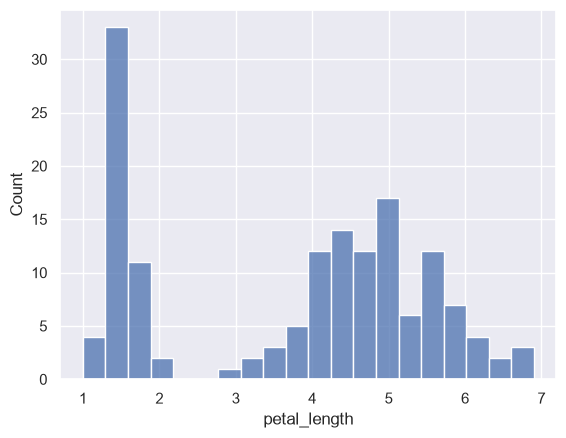

In [65]:
sns.histplot(data=df, x='petal_length', bins=20)

#KDE(kernel density estimation)
수집한 데이터의 분포를 매끄러운 곡선 형태로 추정하여 나타내는 통계학적 방법
히스토그램의 단점을 보완한 그래프

##커널
하나의 데이터 포인트를 대표하는 원형 형태의 작은 함수(곡선)을 의미
데이터 포인트 하나가 관측되었을때, 이 값 근처에도 유사한 값이 나타날 가능성이 높다는 것을 나타냄

<Axes: xlabel='petal_length', ylabel='Count'>

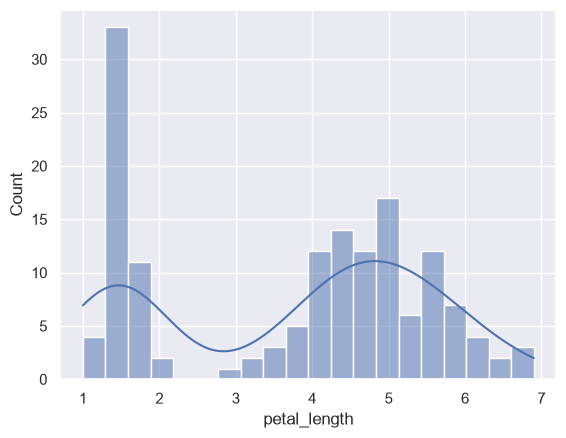

In [66]:
sns.histplot(data=df, x='petal_length', bins=20, kde=True)

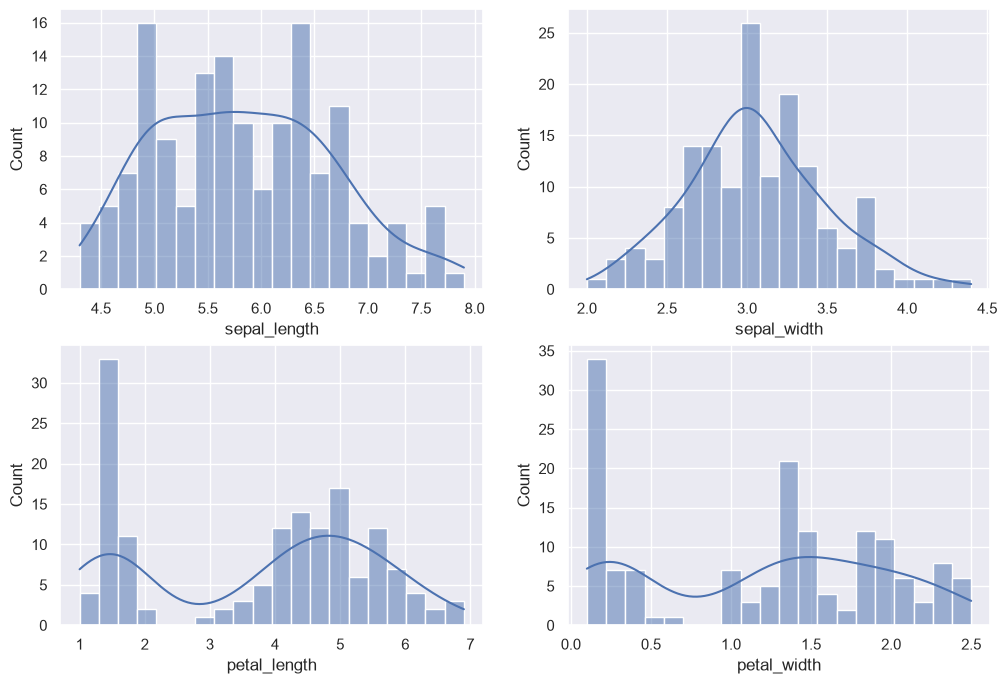

In [67]:
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(12,8))

for ax, column_name in zip(axes.flat, numeric_col):
    sns.histplot(data=df, x=column_name, bins=20, kde=True, ax=ax)



<Axes: xlabel='sepal_length'>

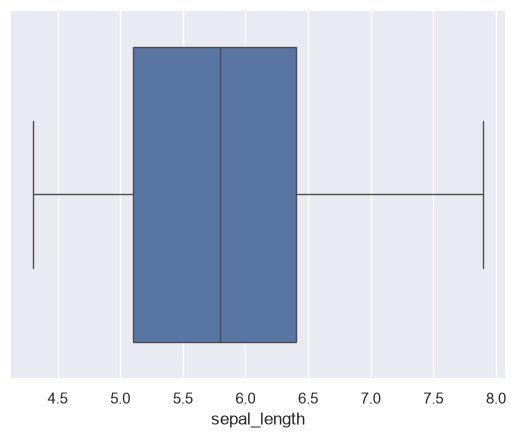

In [68]:
sns.boxplot(data=df, x='sepal_length')

In [69]:
q1= df['sepal_width'].quantile(0.25)
q3= df['sepal_width'].quantile(0.75)

iqr=q3-q1
lower_bound= q1-1.5*iqr
upper_bound= q3+1.5*iqr

print(f'q1={q1},q2={q3},iqr={iqr}, lower={lower_bound},upper={upper_bound}')

q1=2.8,q2=3.3,iqr=0.5, lower=2.05,upper=4.05


In [70]:
outlier = df[(df['sepal_width']<lower_bound) | (df['sepal_width']>upper_bound)]

outlier

,sepal_length,sepal_width,petal_length,petal_width,species
15,5.7,4.4,1.5,0.4,setosa
32,5.2,4.1,1.5,0.1,setosa
33,5.5,4.2,1.4,0.2,setosa
60,5.0,2.0,3.5,1.0,versicolor


In [73]:
for col_name in numeric_col:
    q1= df[col_name].quantile(0.25)
    q3= df[col_name].quantile(0.75)

    iqr=q3-q1
    lower_bound= q1-1.5*iqr
    upper_bound= q3+1.5*iqr

    # outlier= df[(df['sepal_width']<lower_bound) | (df['sepal_width']>upper_bound)]
    out_count= ((df[col_name]<lower_bound) | (df[col_name]>upper_bound)).sum()
    print(col_name,out_count)

sepal_length 0
sepal_width 4
petal_length 0
petal_width 0


<Axes: >

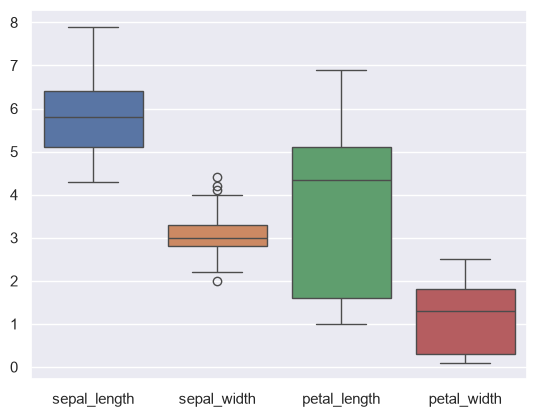

In [74]:
sns.boxplot(data=df[numeric_col])

<Axes: xlabel='petal_length', ylabel='petal_width'>

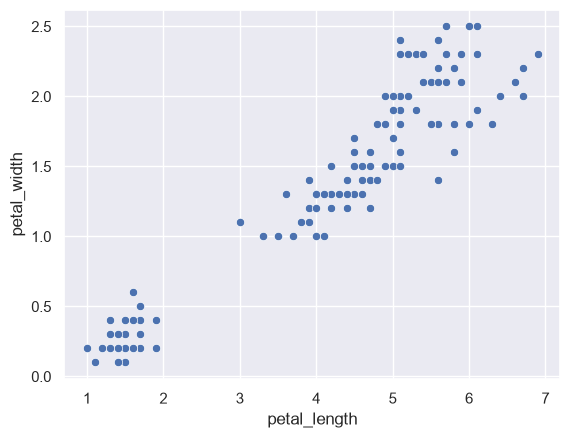

In [75]:
#수치형+수치형

sns.scatterplot(data=df, x='petal_length', y='petal_width')

In [80]:
corr_df = df['petal_length'].corr(df['petal_width'])

corr_df.round(2)

np.float64(0.96)

#회귀
하나 이상의 독립변수가 다른 변수에 미치는 영향을 수식으로 모델링하여 추정하는 기법
##회귀선
산점도 상에서 흩어져 있는 데이터들의 전체적인 추세를 그린 최적의 선

<Axes: xlabel='petal_length', ylabel='petal_width'>

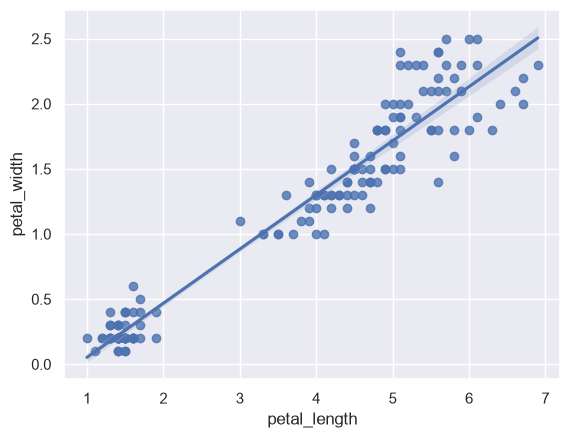

In [82]:
sns.regplot(data=df, x='petal_length', y='petal_width')

<Axes: xlabel='sepal_length', ylabel='petal_width'>

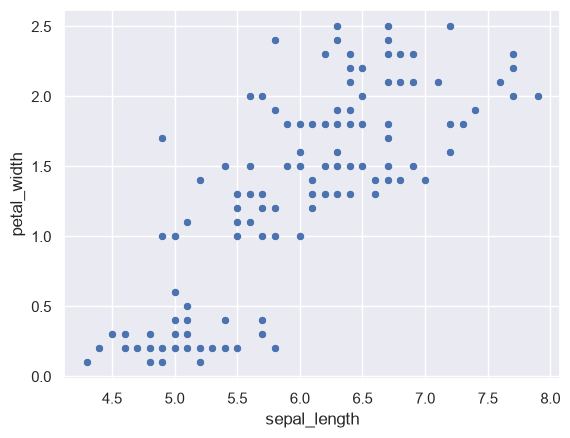

In [84]:
sns.scatterplot(data=df, x='sepal_length', y='petal_width')

In [ ]:
round(df['sepal_length'].corr(df['petal_length']),2)



np.float64(0.87)

In [90]:
df.groupby('species')[numeric_col].mean().round(2)

,sepal_length,sepal_width,petal_length,petal_width
species,,,,
setosa,5.01,3.43,1.46,0.25
versicolor,5.94,2.77,4.26,1.33
virginica,6.59,2.97,5.55,2.03


<Axes: xlabel='species', ylabel='petal_length'>

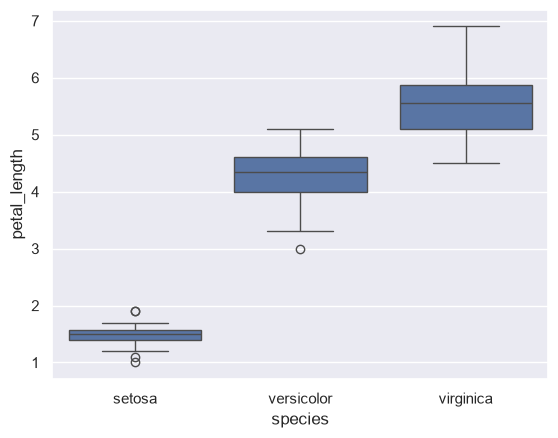

In [91]:
sns.boxplot(data=df,
            x='species',y='petal_length')

<Axes: xlabel='species', ylabel='petal_length'>

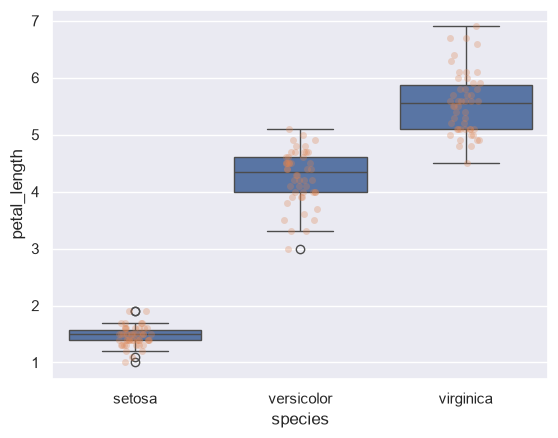

In [92]:
ax= sns.boxplot(data=df,
                x='species', y= 'petal_length')

sns.stripplot(data=df, x='species', y='petal_length', alpha=0.3,
               ax=ax)

<Axes: xlabel='species', ylabel='petal_length'>

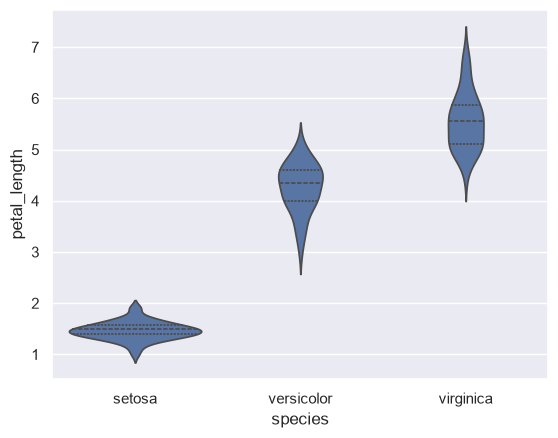

In [93]:
sns.violinplot(data=df, x='species', y= 'petal_length', inner='quart')

<Axes: xlabel='petal_length', ylabel='Count'>

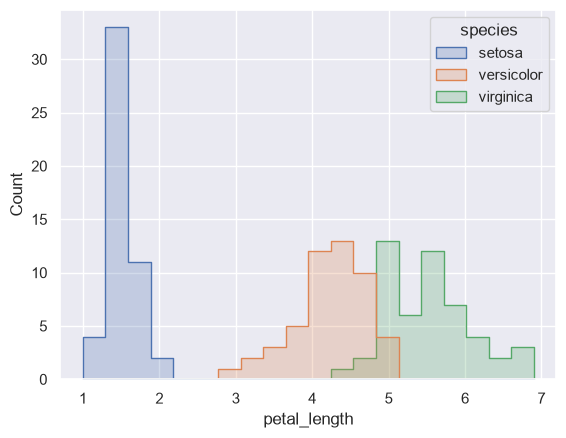

In [99]:
sns.histplot(data=df, x='petal_length', hue='species', bins=20, element='step')

<Axes: xlabel='petal_length', ylabel='petal_width'>

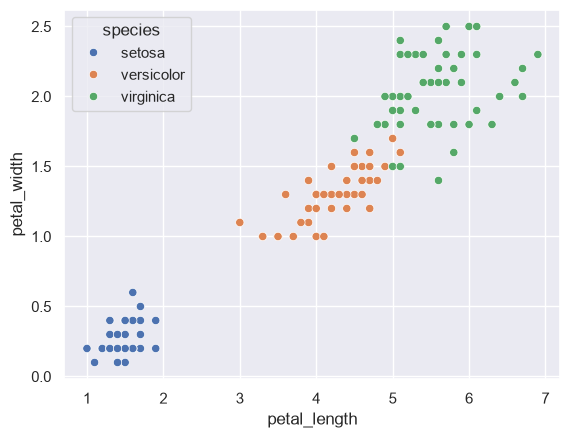

In [100]:
#품종별 꽃잎의 너비와 길이 상관관계

sns.scatterplot(data=df, x='petal_length', y='petal_width', hue='species')

<Axes: xlabel='sepal_length', ylabel='sepal_width'>

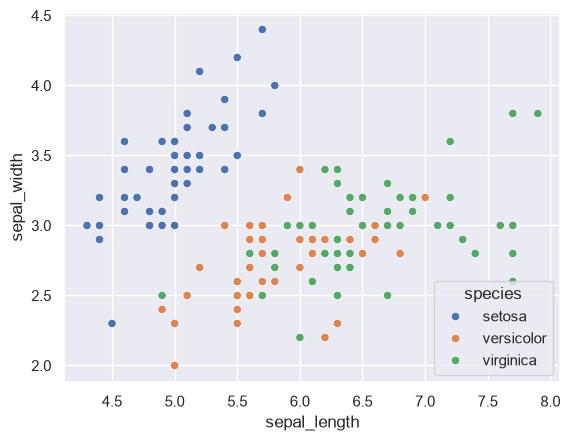

In [101]:
sns.scatterplot(data=df, x='sepal_length', y='sepal_width', hue='species')

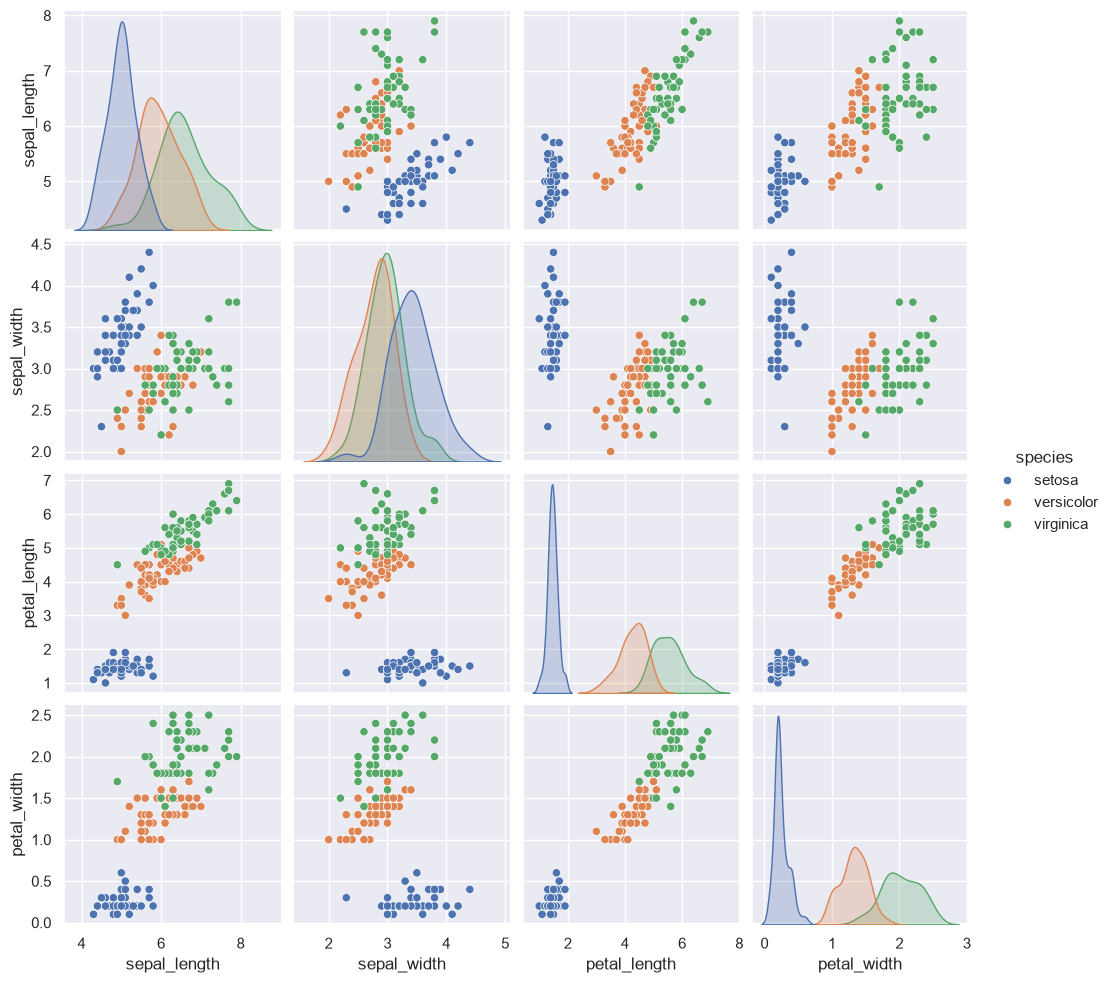

In [103]:
sns.pairplot(data=df, vars=numeric_col, hue='species',)

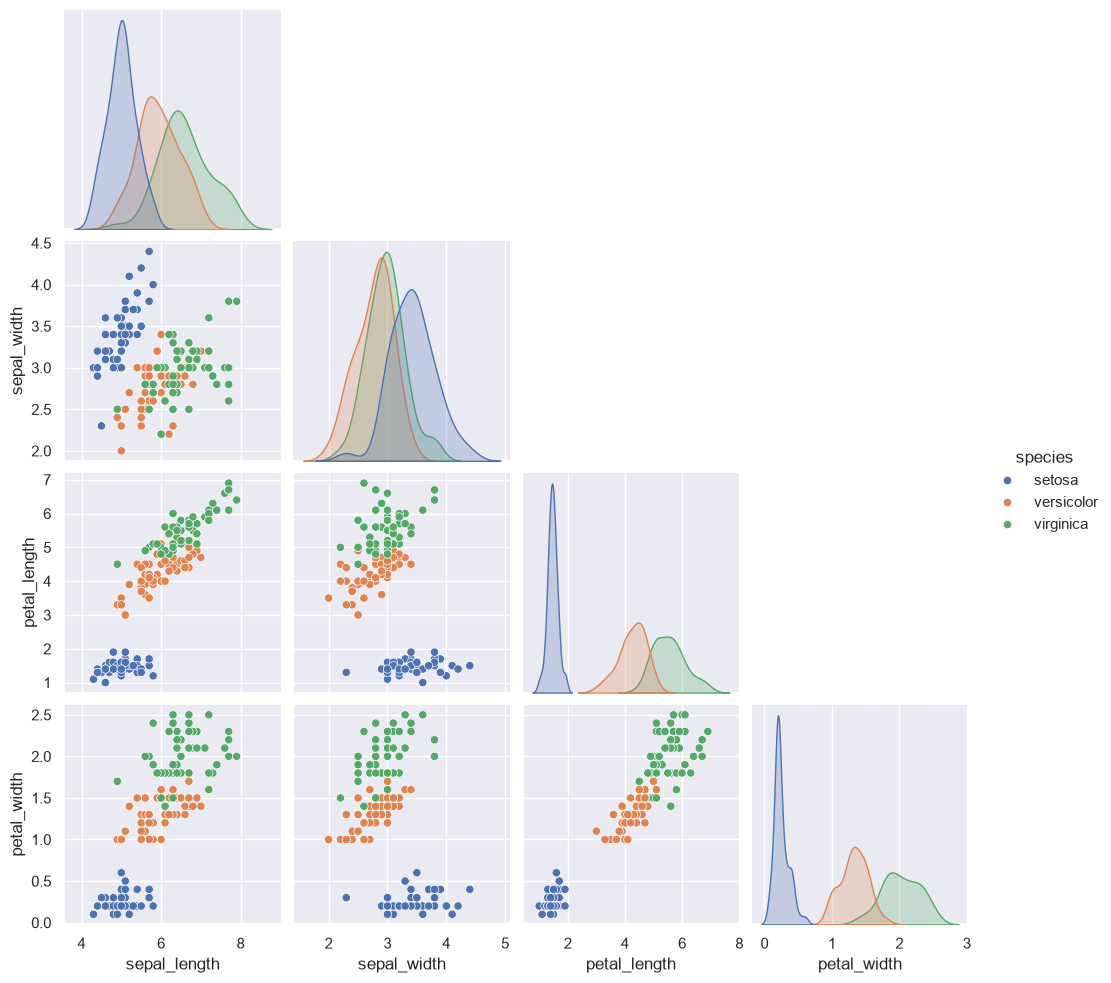

In [104]:
sns.pairplot(data=df, vars=numeric_col, hue='species',corner=True)

대각선 품종별 변수 분포
비대각선 수치형 변수 사이의 관계
색상그룹 품종이 서로 분리되는 영역이 어디인지
겹치는 영역 품종 구분이 어려운 변수 조합 확인

In [109]:
matrix=df[numeric_col].corr().round(2)

<Axes: >

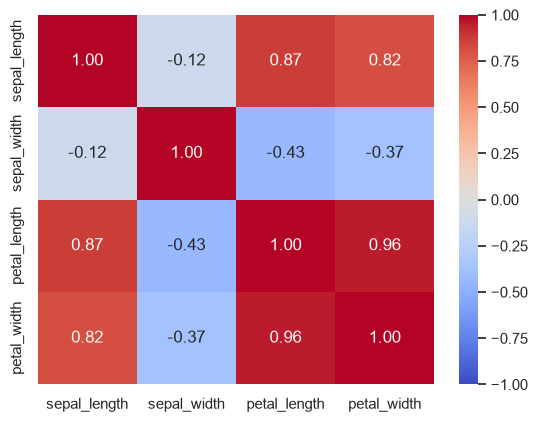

In [113]:
sns.heatmap(data=matrix, annot=True, fmt='.2f',vmax=1,vmin=-1,center=0,cmap='coolwarm')

In [114]:
#꽃잎 길이는 품종마다 뚜렷한 차이를 보인다

petal_mean = df.groupby('species')['petal_length'].mean().round(2)

petal_mean

species
setosa        1.46
versicolor    4.26
virginica     5.55
Name: petal_length, dtype: float64

<Axes: xlabel='species', ylabel='petal_length'>

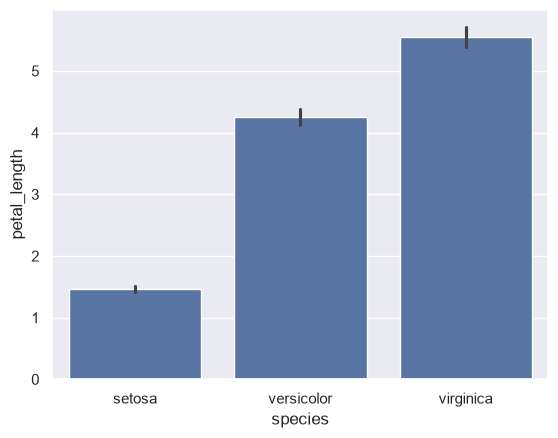

In [115]:
order = petal_mean.index

sns.barplot(data=df, x='species',y='petal_length',order=order,estimator='mean')

<Axes: xlabel='species', ylabel='petal_length'>

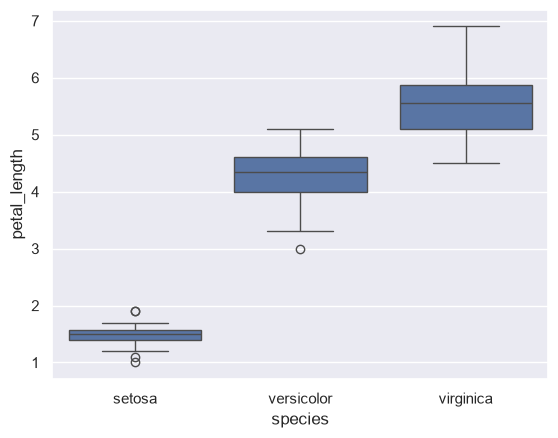

In [116]:
sns.boxplot(data=df, x='species',y='petal_length')

막대그래프 : 평균의 차이
상자그래프,바이올린그래프 : 분포의 차이 강조
산점도 : 두 변수 간의 관계
회귀선 : 선형 관계

<Axes: xlabel='species', ylabel='petal_length'>

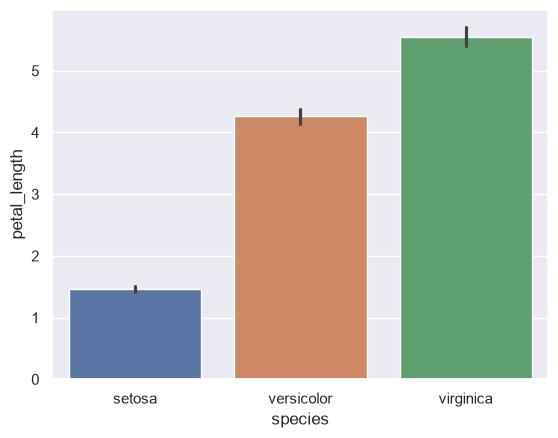

In [117]:


sns.barplot(data=df, x='species',y='petal_length',hue='species',estimator='mean',legend=False)